# Live Exploratory Data Analysis (EDA) with `yfinance`

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Fetching Live Historical Data
We will pull the last 2 years of daily trading data for **Tata Consultancy Services (TCS)**. Note that on Yahoo Finance, Indian stocks listed on the NSE require the `.NS` suffix.

In [2]:
ticker_symbol = 'TCS.NS'
stock = yf.Ticker(ticker_symbol)

# Fetch 2 years of historical data
df = stock.history(period="1y")
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-02 00:00:00+05:30,3425.613563,3445.042221,3412.129606,3425.565186,1764313,0.0,0.0
2025-04-03 00:00:00+05:30,3374.384243,3385.016791,3282.702583,3289.468750,4537821,0.0,0.0
2025-04-04 00:00:00+05:30,3250.273336,3286.085502,3185.414699,3189.184326,5317367,0.0,0.0
2025-04-07 00:00:00+05:30,2996.445437,3181.451683,2953.963621,3164.681396,6623955,0.0,0.0
2025-04-08 00:00:00+05:30,3191.746063,3237.127665,3146.557732,3182.949951,5557558,0.0,0.0


In [3]:
print(f"Data shape: {df.shape}")
df.describe()

Data shape: (248, 7)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,248.000000,248.000000,248.000000,248.000000,2.480000e+02,248.000000,248.0
mean,3066.836374,3089.985793,3037.491505,3061.579953,3.036495e+06,0.439516,0.0
std,257.964596,256.407922,257.582046,258.854703,1.554703e+06,4.193253,0.0
min,2365.000000,2398.000000,2346.199951,2356.000000,0.000000e+00,0.000000,0.0
25%,2970.298717,2992.926955,2946.154153,2966.115479,2.103823e+06,0.000000,0.0
50%,3091.656684,3113.770511,3074.962228,3091.578247,2.736406e+06,0.000000,0.0
75%,3250.430566,3262.466910,3215.102969,3228.164856,3.481093e+06,0.000000,0.0
max,3499.461319,3509.224132,3427.643493,3499.461426,1.116874e+07,57.000000,0.0


## 2. Advanced Price & Volume Analysis
Let's create a combined chart featuring both the Closing Price and the Trading Volume as subplots.

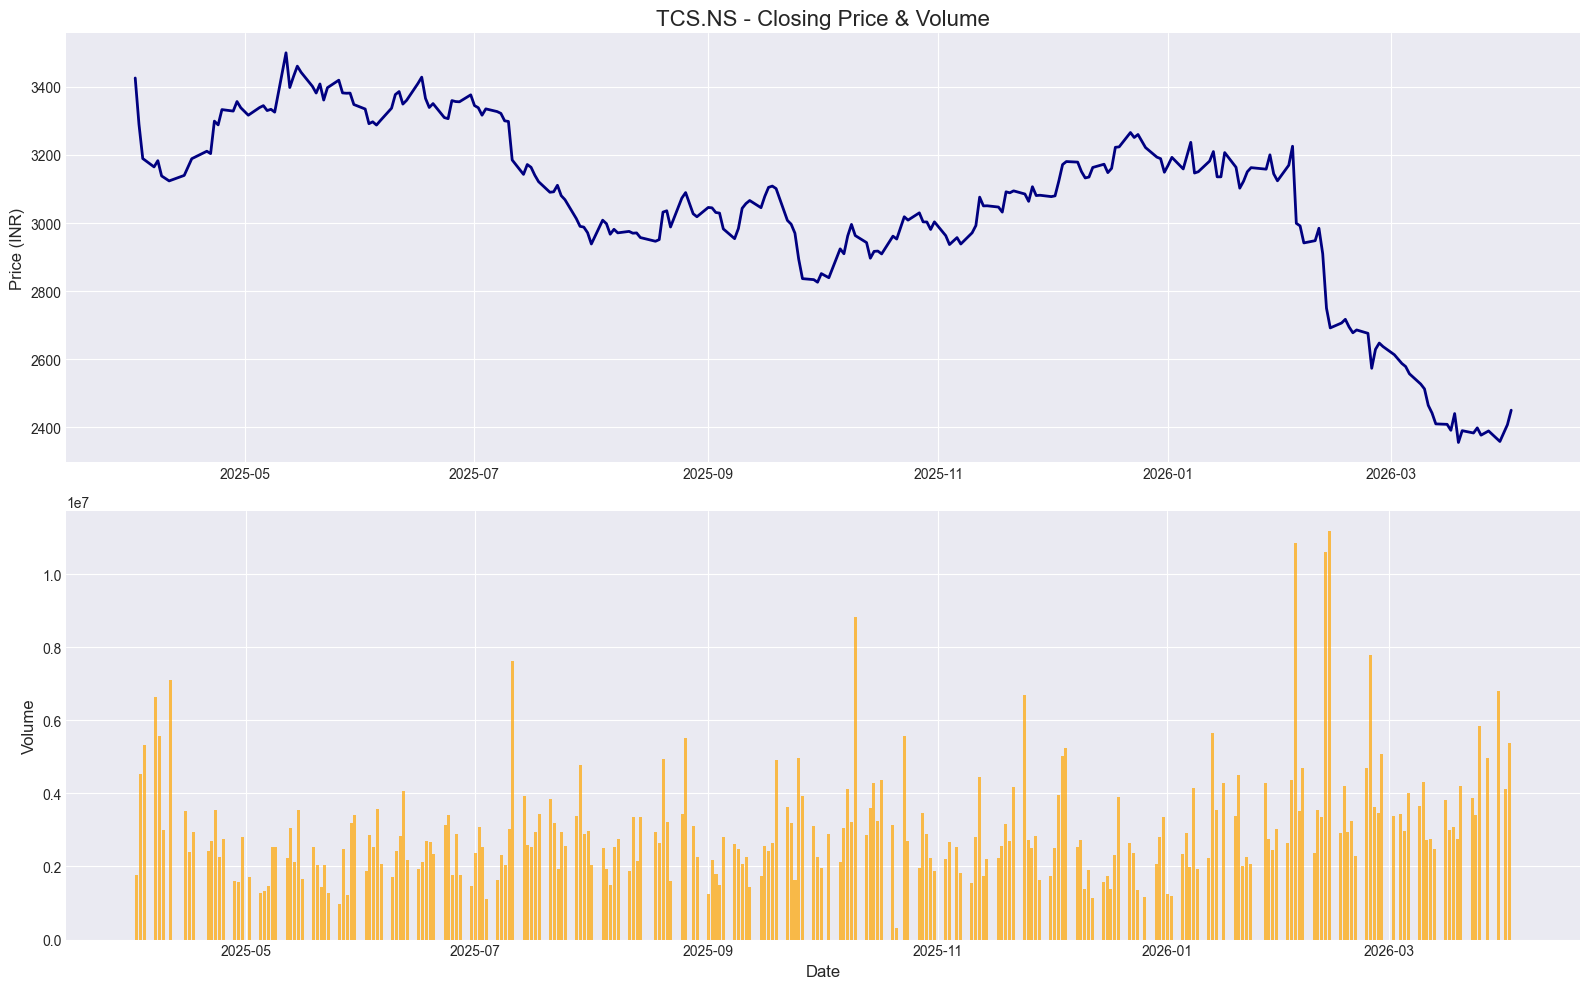

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [1, 1]})

# Price Subplot
ax1.plot(df.index, df['Close'], color='navy', linewidth=2)
ax1.set_title(f'{ticker_symbol} - Closing Price & Volume', fontsize=16)
ax1.set_ylabel('Price (INR)', fontsize=12)

# Volume Subplot
ax2.bar(df.index, df['Volume'], color='orange', alpha=0.7)
ax2.set_ylabel('Volume', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Moving Averages & Trend Indicators
We calculate the 50-day (short/medium term) and 200-day (long term) moving averages. A "Golden Cross" (50-day crossing above 200-day) is often seen as a bullish signal.

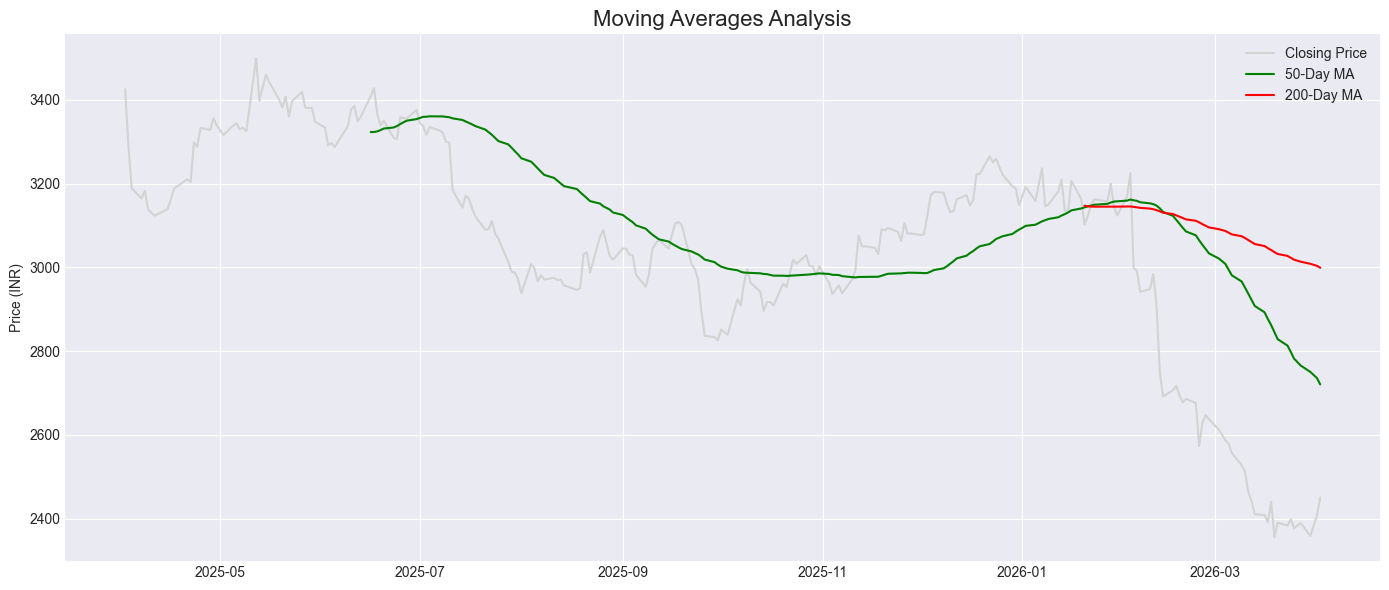

In [5]:
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], color='lightgray', label='Closing Price')
plt.plot(df.index, df['MA_50'], color='green', label='50-Day MA')
plt.plot(df.index, df['MA_200'], color='red', label='200-Day MA')
plt.title('Moving Averages Analysis', fontsize=16)
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Return Distribution & Rolling Volatility
Volatility defines the risk of the stock. We look at the daily return distribution and how the 30-day volatility changes over time.

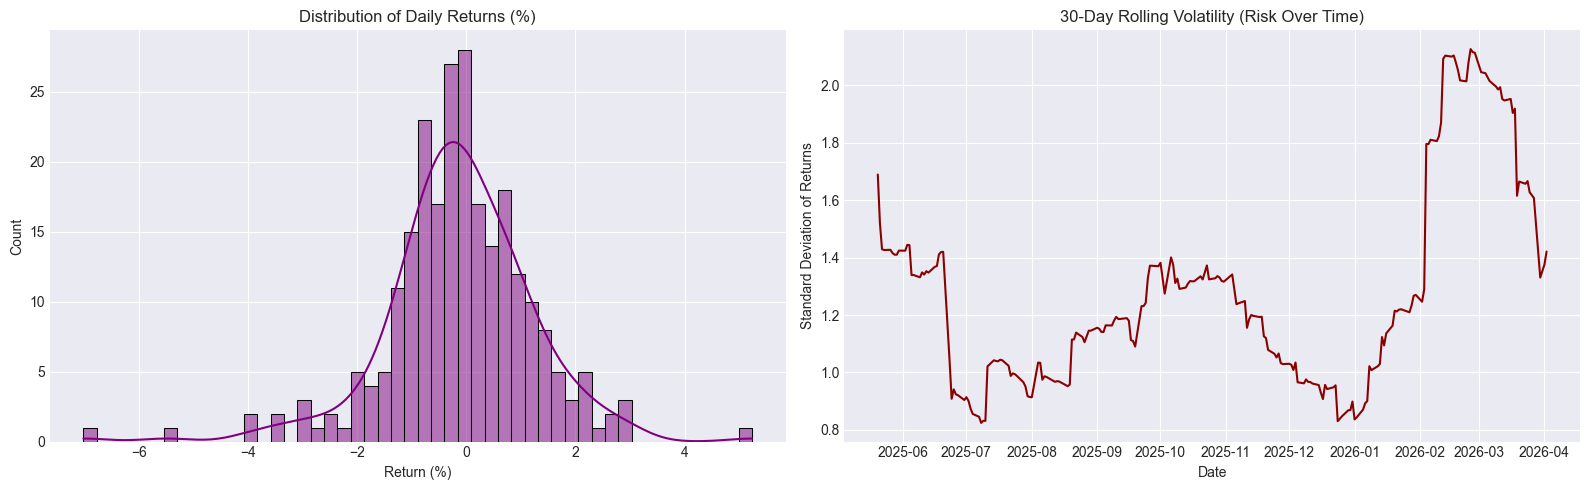

In [6]:
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Rolling_Vol_30d'] = df['Daily_Return'].rolling(window=30).std()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of returns
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='purple', ax=ax1)
ax1.set_title('Distribution of Daily Returns (%)')
ax1.set_xlabel('Return (%)')

# Rolling Volatility over time
ax2.plot(df.index, df['Rolling_Vol_30d'], color='darkred')
ax2.set_title('30-Day Rolling Volatility (Risk Over Time)')
ax2.set_xlabel('Date')
ax2.set_ylabel('Standard Deviation of Returns')

plt.tight_layout()
plt.show()

## 5. Multi-Stock Correlation (IT Sector Analysis)
Stocks in the same sector often move together. Let's download data for top Indian IT companies and generate a correlation heatmap of their daily returns.

[*********************100%***********************]  5 of 5 completed


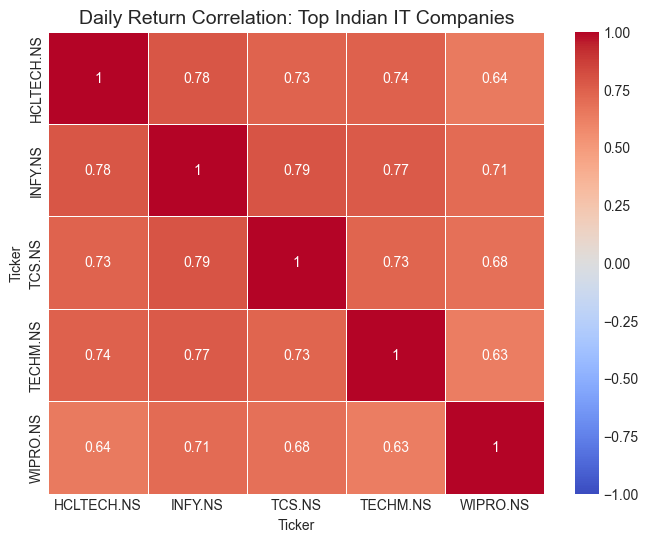

In [7]:
it_tickers = ['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS', 'TECHM.NS']

# Download closing prices for all tickers in one go
it_data = yf.download(it_tickers, period="1y")['Close']

# Calculate daily percentage returns
it_returns = it_data.pct_change().dropna()

# Calculate the correlation matrix
correlation_matrix = it_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Daily Return Correlation: Top Indian IT Companies', fontsize=14)
plt.show()

## 6. Daily Returns Distribution
This plot helps us understand the volatility and frequency of price changes. We use a histogram with a Kernel Density Estimate (KDE).

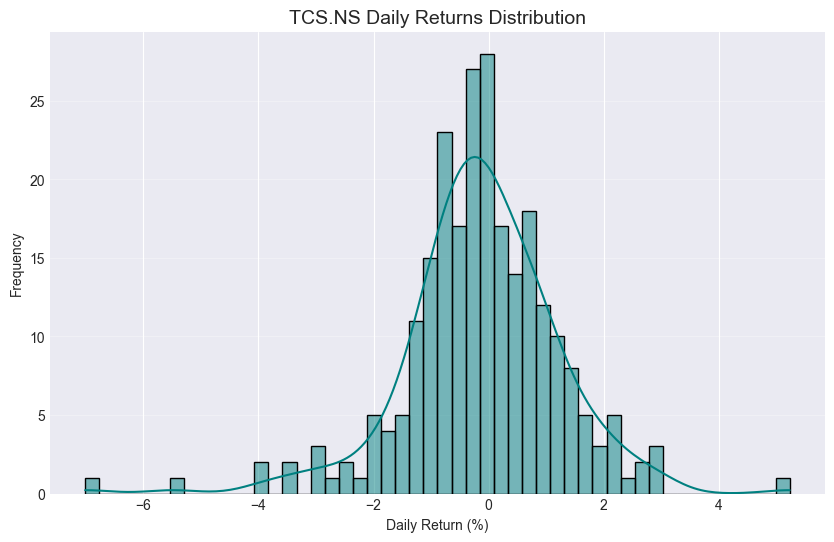

In [27]:
df['Daily_Return'] = df['Close'].pct_change() * 100

plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True, color='teal')
plt.title(f'{ticker_symbol} Daily Returns Distribution', fontsize=14)
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 7. Cumulative Returns Analysis
Visualizing the growth of a hypothetical ₹1 investment over time.

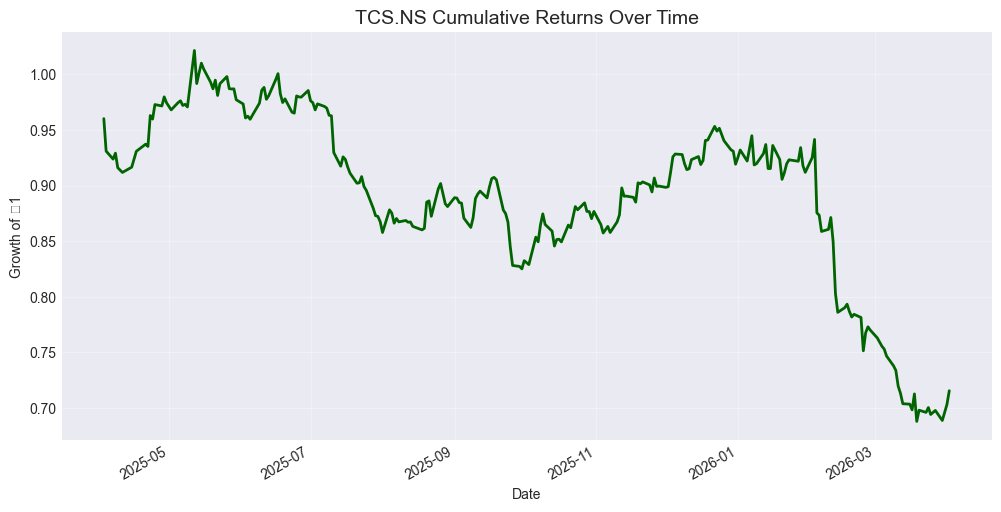

In [28]:
df['Cumulative_Return'] = (1 + df['Daily_Return']/100).cumprod()

plt.figure(figsize=(12, 6))
df['Cumulative_Return'].plot(color='darkgreen', linewidth=2)
plt.title(f'{ticker_symbol} Cumulative Returns Over Time', fontsize=14)
plt.ylabel('Growth of ₹1')
plt.grid(alpha=0.3)
plt.show()

## 8. Shareholding Pattern (Estimate)
Visualizing the ownership structure of the company using values from yfinance.

In [32]:
holders_data = stock.major_holders
if holders_data is not None:
    try:
        insiders = holders_data.set_index(0).loc['insidersPercentHeld', 1]
        institutions = holders_data.set_index(0).loc['institutionsPercentHeld', 1]
        others = 1.0 - (insiders + institutions)
        
        labels = ['Insiders (Promoters)', 'Institutions', 'Retail/Others']
        sizes = [insiders, institutions, max(0, others)]
        
        plt.figure(figsize=(8, 8))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, 
                colors=['#ff9999','#66b3ff','#99ff99'], explode=(0.05, 0, 0))
        plt.title(f'{ticker_symbol} Major Shareholding Pattern', fontsize=14)
        plt.show()
    except Exception as e:
        print(f"Detailed breakdown not easily parsable: {e}")
        print(holders_data)
else:
    print("Shareholding data not available for this ticker.")

Detailed breakdown not easily parsable: 'None of [0] are in the columns'
Breakdown                         Value
insidersPercentHeld             0.71789
institutionsPercentHeld         0.16980
institutionsFloatPercentHeld    0.60190
institutionsCount             335.00000


## 9. 30-Day Rolling Volatility
Tracking how the investment risk (standard deviation of returns) fluctuates over time.

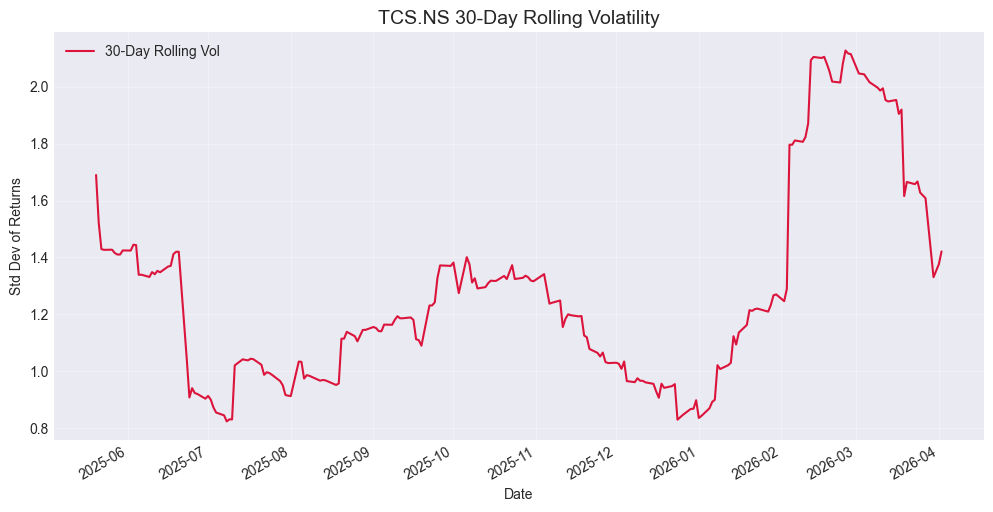

In [30]:
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

plt.figure(figsize=(12, 6))
df['Volatility_30d'].plot(color='crimson', label='30-Day Rolling Vol')
plt.title(f'{ticker_symbol} 30-Day Rolling Volatility', fontsize=14)
plt.ylabel('Std Dev of Returns')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Monthly Return Seasonality
Analyzing if there are specific months that historically perform better or worse.

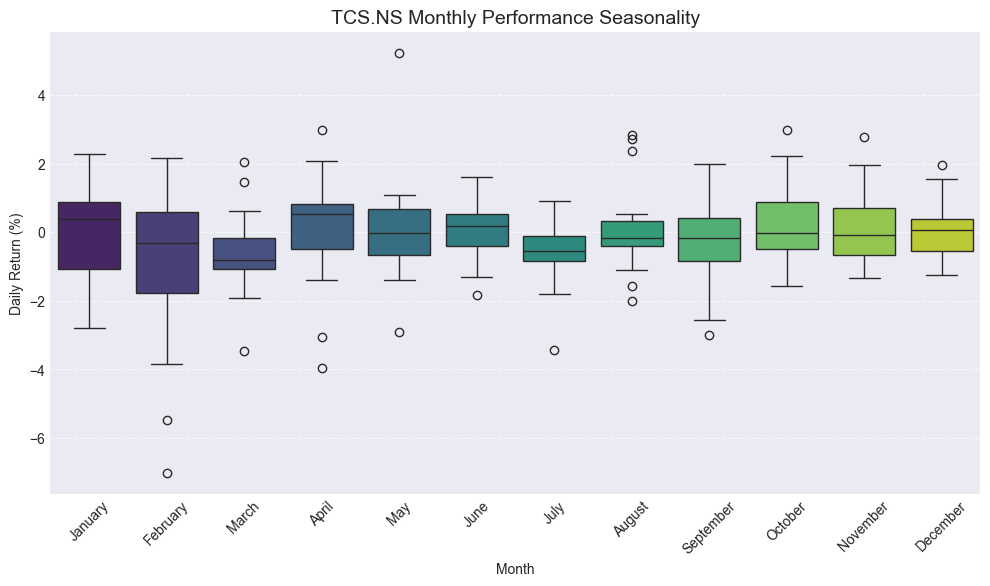

In [34]:
df['Month'] = df.index.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Daily_Return', data=df, order=month_order, palette='viridis')
plt.xticks(rotation=45)
plt.title(f'{ticker_symbol} Monthly Performance Seasonality', fontsize=14)
plt.ylabel('Daily Return (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()